# Hyperparameter Tuning for Breast Cancer Classification

## Project Overview

The goal is to improve classification performance by selecting better model settings instead of relying only on default parameters.

The project uses the breast cancer diagnostic dataset. The target is recoded so that:

- `1 = malignant`
- `0 = benign`

This makes malignant tumors the positive class, which is useful because identifying malignant cases is usually the most important goal in a medical classification problem.

## Models Tuned

- Logistic Regression
- K Nearest Neighbors
- Support Vector Machine
- Decision Tree
- Random Forest
- Gradient Boosting

## Tuning Methods

- Baseline model comparison
- Grid Search Cross Validation
- Randomized Search Cross Validation
- Final test set evaluation

## Evaluation Metrics

- Accuracy
- Precision
- Recall
- F1 Score
- ROC AUC
- Confusion Matrix


## Why Hyperparameter Tuning?

Model parameters are learned from the data. Hyperparameters are settings chosen before training the model.

For example:

- KNN needs a value for `n_neighbors`
- Random Forest needs values for `n_estimators`, `max_depth`, and `min_samples_leaf`
- SVM needs values for `C`, `gamma`, and `kernel`

Poor hyperparameter choices can lead to underfitting or overfitting. Hyperparameter tuning helps find model settings that generalize better to unseen data.

### Import libraries

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV,
    RandomizedSearchCV
)

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

### Load the dataset

In [35]:
df = pd.read_csv("breast_cancer_classification.csv")

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnosis,diagnosis_label
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0,malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0,malignant


In [36]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         569 non-null

In [37]:
df.shape

(569, 32)

In [38]:
df["diagnosis_label"].value_counts()

diagnosis_label
benign       357
malignant    212
Name: count, dtype: int64

The original dataset uses: 

0 = malignant, 1 = benign

Let's recode it to:

1 = malignant, 0 = benign

In [39]:
X = df.drop(columns=["diagnosis", "diagnosis_label"])

y = np.where(df["diagnosis_label"] == "malignant", 1, 0)

y = pd.Series(y, name="malignant")

In [40]:
y.value_counts()

malignant
0    357
1    212
Name: count, dtype: int64

In [41]:
y.value_counts(normalize=True)

malignant
0    0.627417
1    0.372583
Name: proportion, dtype: float64

### Train-test split

In [42]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("Training data shape:", X_train.shape)
print("Test data shape:", X_test.shape)

Training data shape: (455, 30)
Test data shape: (114, 30)


### An evaluation function

In [43]:
def evaluate_model(model_name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
    else:
        y_proba = model.decision_function(X_test)
    
    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC AUC": roc_auc_score(y_test, y_proba)
    }

### Baseline models before tuning

In [44]:
baseline_models = {
    "Logistic Regression": Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(max_iter=1000, random_state=42))
        ]
    ),
    
    "KNN": Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            ("model", KNeighborsClassifier())
        ]
    ),
    
    "SVM": Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            ("model", SVC(probability=True, random_state=42))
        ]
    ),
    
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    
    "Random Forest": RandomForestClassifier(random_state=42, n_jobs=-1),
    
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

In [45]:
baseline_results = []

for model_name, model in baseline_models.items():
    model.fit(X_train, y_train)
    
    results = evaluate_model(
        model_name=model_name,
        model=model,
        X_test=X_test,
        y_test=y_test
    )
    
    baseline_results.append(results)

baseline_results_df = pd.DataFrame(baseline_results)

baseline_results_df.sort_values(by="ROC AUC", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.964912,0.975000,0.928571,0.951220,0.996032
5,Gradient Boosting,0.964912,1.000000,0.904762,0.950000,0.994709
2,SVM,0.973684,1.000000,0.928571,0.962963,0.994709
4,Random Forest,0.973684,1.000000,0.928571,0.962963,0.992890
1,KNN,0.956140,0.974359,0.904762,0.938272,0.982308
3,Decision Tree,0.929825,0.904762,0.904762,0.904762,0.924603


# Cross validation

We use stratified cross validation, so each fold keeps a similar class distribution. For medical classification, recall can be very important because we want to correctly identify malignant cases. However, ROC AUC is a good general metric for overall class separation.

In [46]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [47]:
scoring_metric = "roc_auc"

## Grid Search Cross Validation

Grid Search tries every combination of hyperparameters that we specify.

### Logistic Regression tuning

In [48]:
logistic_pipeline = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=10000,
            solver="lbfgs",
            random_state=42 )) 
    ]
)

logistic_param_grid = {
    "model__C": [0.001, 0.01, 0.1, 1, 10, 100]
}

logistic_grid = GridSearchCV(
    estimator=logistic_pipeline,
    param_grid=logistic_param_grid,
    scoring=scoring_metric,
    cv=cv,
    n_jobs=-1,
    refit=True
)

logistic_grid.fit(X_train, y_train)

print("Best Logistic Regression Parameters")
print("-----------------------------------")
print(logistic_grid.best_params_)
print(f"Best CV ROC AUC: {logistic_grid.best_score_:.4f}")

Best Logistic Regression Parameters
-----------------------------------
{'model__C': 1}
Best CV ROC AUC: 0.9958


### KNN tuning

In [49]:
knn_pipeline = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier()) ])

knn_param_grid = {
    "model__n_neighbors": [3, 5, 7, 9, 11, 15],
    "model__weights": ["uniform", "distance"],
    "model__metric": ["euclidean", "manhattan"]
}

knn_grid = GridSearchCV(
    estimator=knn_pipeline,
    param_grid=knn_param_grid,
    scoring=scoring_metric,
    cv=cv,
    n_jobs=-1,
    refit=True
)

knn_grid.fit(X_train, y_train)

print("Best KNN Parameters")
print("-------------------")
print(knn_grid.best_params_)
print(f"Best CV ROC AUC: {knn_grid.best_score_:.4f}")

Best KNN Parameters
-------------------
{'model__metric': 'euclidean', 'model__n_neighbors': 11, 'model__weights': 'distance'}
Best CV ROC AUC: 0.9892


### SVM tuning

In [50]:
svm_pipeline = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("model", SVC(probability=True, random_state=42)) ])

svm_param_grid = {
    "model__C": [0.01, 0.1, 1, 10, 100],
    "model__gamma": ["scale", 0.001, 0.01, 0.1, 1],
    "model__kernel": ["rbf", "linear"]
}

svm_grid = GridSearchCV(
    estimator=svm_pipeline,
    param_grid=svm_param_grid,
    scoring=scoring_metric,
    cv=cv,
    n_jobs=-1,
    refit=True )

svm_grid.fit(X_train, y_train)

print("Best SVM Parameters")
print("-------------------")
print(svm_grid.best_params_)
print(f"Best CV ROC AUC: {svm_grid.best_score_:.4f}")

Best SVM Parameters
-------------------
{'model__C': 100, 'model__gamma': 0.001, 'model__kernel': 'rbf'}
Best CV ROC AUC: 0.9960


## Randomized Search Cross Validation

Randomized Search samples from a range of hyperparameters instead of trying every combination. It is useful when the search space is large.

### Decision Tree tuning

In [51]:
decision_tree_param_dist = {
    "max_depth": [None, 2, 3, 4, 5, 7, 10],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5, 10],
    "criterion": ["gini", "entropy"] }

decision_tree_random = RandomizedSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_distributions=decision_tree_param_dist,
    n_iter=40,
    scoring=scoring_metric,
    cv=cv,
    random_state=42,
    n_jobs=-1,
    refit=True )

decision_tree_random.fit(X_train, y_train)

print("Best Decision Tree Parameters")
print("-----------------------------")
print(decision_tree_random.best_params_)
print(f"Best CV ROC AUC: {decision_tree_random.best_score_:.4f}")

Best Decision Tree Parameters
-----------------------------
{'min_samples_split': 20, 'min_samples_leaf': 5, 'max_depth': 5, 'criterion': 'gini'}
Best CV ROC AUC: 0.9615


### Random Forest tuning

In [52]:
random_forest_param_dist = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [None, 3, 5, 7, 10],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4, 8],
    "max_features": ["sqrt", "log2", None],
    "bootstrap": [True, False] }

random_forest_random = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_distributions=random_forest_param_dist,
    n_iter=60,
    scoring=scoring_metric,
    cv=cv,
    random_state=42,
    n_jobs=-1,
    refit=True )

random_forest_random.fit(X_train, y_train)

print("Best Random Forest Parameters")
print("-----------------------------")
print(random_forest_random.best_params_)
print(f"Best CV ROC AUC: {random_forest_random.best_score_:.4f}")

Best Random Forest Parameters
-----------------------------
{'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None, 'bootstrap': False}
Best CV ROC AUC: 0.9891


### Gradient Boosting tuning

In [53]:
gradient_boosting_param_dist = {
    "n_estimators": [50, 100, 200, 300],
    "learning_rate": [0.001, 0.01, 0.05, 0.1],
    "max_depth": [1, 2, 3, 4],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5],
    "subsample": [0.6, 0.8, 1.0] }

gradient_boosting_random = RandomizedSearchCV(
    estimator=GradientBoostingClassifier(random_state=42),
    param_distributions=gradient_boosting_param_dist,
    n_iter=60,
    scoring=scoring_metric,
    cv=cv,
    random_state=42,
    n_jobs=-1,
    refit=True
)

gradient_boosting_random.fit(X_train, y_train)

print("Best Gradient Boosting Parameters")
print("---------------------------------")
print(gradient_boosting_random.best_params_)
print(f"Best CV ROC AUC: {gradient_boosting_random.best_score_:.4f}")

Best Gradient Boosting Parameters
---------------------------------
{'subsample': 0.8, 'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 5, 'max_depth': 3, 'learning_rate': 0.1}
Best CV ROC AUC: 0.9941


### Compare tuned models on the test set

In [54]:
tuned_models = {
    "Tuned Logistic Regression": logistic_grid.best_estimator_,
    "Tuned KNN": knn_grid.best_estimator_,
    "Tuned SVM": svm_grid.best_estimator_,
    "Tuned Decision Tree": decision_tree_random.best_estimator_,
    "Tuned Random Forest": random_forest_random.best_estimator_,
    "Tuned Gradient Boosting": gradient_boosting_random.best_estimator_
}

In [55]:
tuned_results = []

for model_name, model in tuned_models.items():
    results = evaluate_model(
        model_name=model_name,
        model=model,
        X_test=X_test,
        y_test=y_test )
    
    tuned_results.append(results)

tuned_results_df = pd.DataFrame(tuned_results)

tuned_results_df.sort_values(by="ROC AUC", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
5,Tuned Gradient Boosting,0.964912,1.000000,0.904762,0.950000,0.997024
0,Tuned Logistic Regression,0.964912,0.975000,0.928571,0.951220,0.996032
2,Tuned SVM,0.973684,1.000000,0.928571,0.962963,0.995701
4,Tuned Random Forest,0.964912,0.975000,0.928571,0.951220,0.994048
1,Tuned KNN,0.947368,0.973684,0.880952,0.925000,0.982308
3,Tuned Decision Tree,0.903509,0.918919,0.809524,0.860759,0.966931


### Compare baseline vs tuned models

In [56]:
baseline_results_df["Type"] = "Baseline"
tuned_results_df["Type"] = "Tuned"

model_comparison = pd.concat(
    [baseline_results_df, tuned_results_df],
    axis=0,
    ignore_index=True )

model_comparison = model_comparison.sort_values(
    by="ROC AUC",
    ascending=False )

model_comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,Type
11,Tuned Gradient Boosting,0.964912,1.000000,0.904762,0.950000,0.997024,Tuned
0,Logistic Regression,0.964912,0.975000,0.928571,0.951220,0.996032,Baseline
6,Tuned Logistic Regression,0.964912,0.975000,0.928571,0.951220,0.996032,Tuned
8,Tuned SVM,0.973684,1.000000,0.928571,0.962963,0.995701,Tuned
5,Gradient Boosting,0.964912,1.000000,0.904762,0.950000,0.994709,Baseline
2,SVM,0.973684,1.000000,0.928571,0.962963,0.994709,Baseline
10,Tuned Random Forest,0.964912,0.975000,0.928571,0.951220,0.994048,Tuned
4,Random Forest,0.973684,1.000000,0.928571,0.962963,0.992890,Baseline
1,KNN,0.956140,0.974359,0.904762,0.938272,0.982308,Baseline
7,Tuned KNN,0.947368,0.973684,0.880952,0.925000,0.982308,Tuned


### Select the best tuned model

In [57]:
best_model_row = tuned_results_df.sort_values(
    by="ROC AUC",
    ascending=False
).iloc[0]

best_model_name = best_model_row["Model"]
best_model = tuned_models[best_model_name]

print("Best Tuned Model")
print("----------------")
print(best_model_name)
print(f"Accuracy:  {best_model_row['Accuracy']:.4f}")
print(f"Precision: {best_model_row['Precision']:.4f}")
print(f"Recall:    {best_model_row['Recall']:.4f}")
print(f"F1 Score:  {best_model_row['F1 Score']:.4f}")
print(f"ROC AUC:   {best_model_row['ROC AUC']:.4f}")

Best Tuned Model
----------------
Tuned Gradient Boosting
Accuracy:  0.9649
Precision: 1.0000
Recall:    0.9048
F1 Score:  0.9500
ROC AUC:   0.9970


### Classification report for the Tuned Gradient Boosting

In [58]:
y_pred_best = best_model.predict(X_test)

print(classification_report(
    y_test,
    y_pred_best,
    target_names=["benign", "malignant"]
))

              precision    recall  f1-score   support

      benign       0.95      1.00      0.97        72
   malignant       1.00      0.90      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114



### Confusion matrix for the Tuned Gradient Boosting

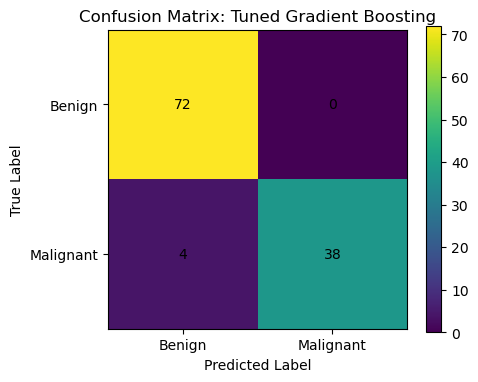

In [59]:
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(5, 4))
plt.imshow(cm)
plt.title(f"Confusion Matrix: {best_model_name}")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.colorbar()

labels = ["Benign", "Malignant"]

plt.xticks([0, 1], labels)
plt.yticks([0, 1], labels)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()

### ROC curve for the Tuned Gradient Boosting

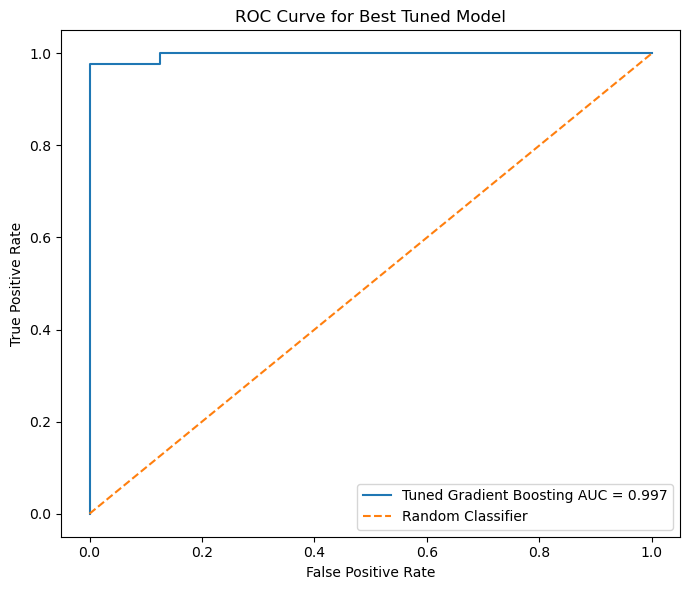

In [60]:
if hasattr(best_model, "predict_proba"):
    y_proba_best = best_model.predict_proba(X_test)[:, 1]
else:
    y_proba_best = best_model.decision_function(X_test)

fpr, tpr, thresholds = roc_curve(y_test, y_proba_best)
auc_score = roc_auc_score(y_test, y_proba_best)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f"{best_model_name} AUC = {auc_score:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Best Tuned Model")
plt.legend()
plt.tight_layout()
plt.show()